# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [40]:
# Uncomment and run if required
#!pip install transformers torchvision torch accelerate

from tqdm import tqdm

In [1]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cpu


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

test_dataset = datasets.FashionMNIST(
    root="data", 
    train=False, 
    download=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_clip  # This uses your provided function to prep images for CLIP
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 217kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.21MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 947kB/s]


If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

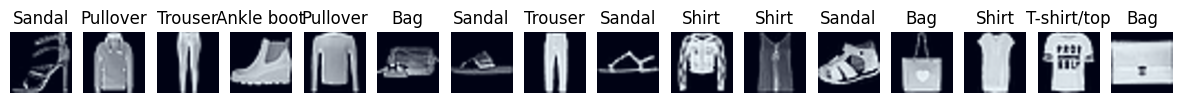

In [ ]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [23]:
def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """    Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=class_names,
                               padding=True,
                               return_tensors="pt").to(device)
    
    with torch.no_grad():
        text_embeddings = clip_model.get_text_features(**tokenized).pooler_output

    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(pixel_values=images).pooler_output

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [24]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors
    return image_feats @ text_feats.T

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    return np.argmax(similarity, axis=1)

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix

text_feats = get_text_embeddings(CLASS_NAMES)

y_true, y_pred = [], []

for pixel_values, labels in test_loader:
    #image embeddings
    image_feats = get_image_embeddings(pixel_values)

    #compute similarity
    similarity = get_cosine_similarity(image_feats, text_feats)

    #Get the predictions
    preds = get_predictions(similarity)
    
    # D. Save the results
    y_pred.extend(preds)
    y_true.extend(labels.cpu().numpy())

# Report the accuracy of the predictions

# Report the accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

Accuracy: 0.6240
Confusion Matrix:
[[769  25   2  95  18  14  19   0  58   0]
 [  0 931   0   5   5  56   0   0   3   0]
 [415  25 306   6 174   7   4   0  63   0]
 [ 56  87   2 504 216  77   2   1  53   2]
 [ 74  19 143   9 690   6   1   0  58   0]
 [  0  31   3   0   1 393   0 414  17 141]
 [338  29  29  79 394  20  42   0  68   1]
 [  0   0   0   0   0  49   0 950   0   1]
 [  0  14   3   0   1  19   0   5 958   0]
 [  0   0   0   0   0   5   0 297   1 697]]


Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?

Answer: The Zero Shot baseline has an accuracy of 0.62 vs 0.88 in my trained cnn. Not as high but impressive for no training. The confusion matrix of the zero shot also shows that items 3, item 4, item 6 and item 7 are wrongly identified, but the rest seems to be good. 

Pros and Cons: In cnn, i need to train, teach it what fashion items look like, but here, it straight away identifies it. Its really good and the accuracy is way better than base cnn. But it can be improved. The downside is the computational time. For a computer like mine, it took me 20 min. 

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

In [30]:
# Create a list of improved, descriptive prompts
IMPROVED_PROMPTS = [
    "a photo of a T-shirt or a top",          #0 T-shirt/top
    "a photo of trousers or pants",           #1 Trouser
    "a photo of a pullover or sweatshirt or cardigan",    #2 Pullover
    "a photo of a women's dress",                     #3 Dress
    "a photo of a women's coat",                      #4 Coat
    "a photo of a sandal or sandals or women's sandals",                    #5 Sandal
    "a photo of a collared shirt",            #6 Collared Shirt 
    "a photo of a sneaker",                   #7 Sneaker
    "a photo of a bag",                       #8 Bag
    "a photo of an ankle boot"                #9 Ankle boot
]

from sklearn.metrics import accuracy_score, confusion_matrix

text_feats = get_text_embeddings(IMPROVED_PROMPTS)

y_true, y_pred = [], []

for pixel_values, labels in test_loader:
    #image embeddings
    image_feats = get_image_embeddings(pixel_values)

    #compute similarity
    similarity = get_cosine_similarity(image_feats, text_feats)

    #Get the predictions
    preds = get_predictions(similarity)
    
    # D. Save the results
    y_pred.extend(preds)
    y_true.extend(labels.cpu().numpy())

# Report the accuracy of the predictions

# Report the accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

Accuracy: 0.6493
Confusion Matrix:
[[439   1 122 158  31  24 207   0  18   0]
 [  0 830  16  23  18 105   0   0   0   8]
 [  6   0 923   6  36  13   2   0  14   0]
 [  6   3  84 559 209 126   4   0   7   2]
 [  1   1 715  19 223  15  14   0  12   0]
 [  0   1  30   0   0 882   0  71   1  15]
 [ 54   3 492  98 156  37 147   0  13   0]
 [  0   0   1   0   0  95   0 897   0   7]
 [  0   1  74   0   8  89   0   1 826   1]
 [  0   0   2   0   0  28   0 203   0 767]]


Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

Answer: The zero shot classification has improved a bit but only by 2%. Its not a significant improvement. 
Which tells me that by adding a word "a photo" would not dent a lot. Which also means that it is searching the photos even without saying 'a photo of'. But descriptions can improve,  dress to women's dress, from correct predictions of 504 from CLASS_NAMES to 559 from IMPROVED_PROMPTS. 

## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [ ]:
# Uncomment the following line to install UMAP if you haven't already
# !pip install umap-learn

Extracting embeddings from test_loader...
Fitting UMAP (reducing dimensions to 2D)...


c:\Users\jesse\DSI\deep_learning\deep-learning-env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\jesse\DSI\deep_learning\deep-learning-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


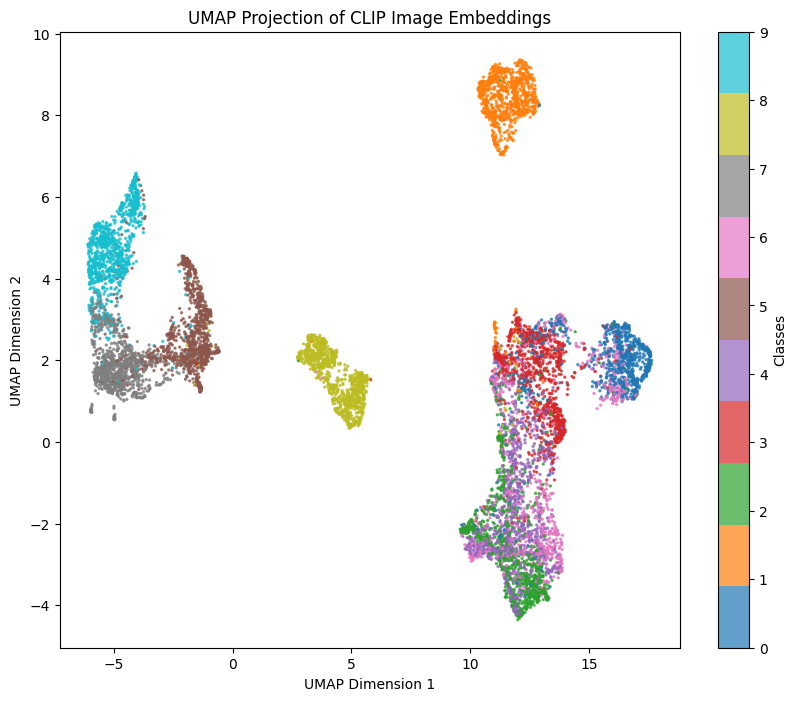

In [31]:
from umap import UMAP
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
all_img_emb = []
all_labels  = []

print("Extracting embeddings from test_loader...")
for pixel_values, labels in test_loader:
    # Use function to get the CLIP features
    img_emb = get_image_embeddings(pixel_values)
    
    # Move to CPU and convert to numpy for UMAP
    all_img_emb.append(img_emb.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

# Combine list of batches into a single large matrix
all_img_emb = np.vstack(all_img_emb)
all_labels = np.array(all_labels)

# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------
print("Fitting UMAP (reducing dimensions to 2D)...")
# n_neighbors controls local vs global structure
# min_dist controls how tightly points are packed
reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d = reducer.fit_transform(all_img_emb)

# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))

# Create the scatter plot
# c=all_labels applies a different color to each category
scatter = plt.scatter(
    embedding_2d[:, 0], 
    embedding_2d[:, 1], 
    c=all_labels, 
    cmap='tab10', 
    s=2, 
    alpha=0.7
)

# Add a colorbar or legend to identify the classes
plt.colorbar(scatter, ticks=range(len(CLASS_NAMES)), label='Classes')
plt.title('UMAP Projection of CLIP Image Embeddings')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')

# Optional: Add class names to the colorbar labels
# (Assuming CLASS_NAMES is defined in your notebook)
# plt.clim(-0.5, 9.5) 

plt.show()

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph. 

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?

ANSWER: Yes, i did notice a challenge. Some classes like trousers or pants are easily recognizable (orange class), or the yellow green like a bag. It is so distinct so it guesses it correctly. However some classes are hard to detect, say the Tshirt and the shirt (Blue and pink) or the sweatshirt. In actual fashion or clothing industry, because they are all tops, there could be overlaps in design muddying the prediction. 

## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

In [32]:
from transformers import CLIPProcessor, CLIPModel

model_id = "openai/clip-vit-large-patch14"

# Load the new larger model and its processor
new_clip_model = CLIPModel.from_pretrained(model_id).to(device)
new_clip_processor = CLIPProcessor.from_pretrained(model_id)

# Update your embedding functions to use 'new_clip_model' and 'new_clip_processor'
# (Or just rename them back to clip_model/clip_processor to keep your old code working)

config.json: 0.00B [00:00, ?B/s]

c:\Users\jesse\DSI\deep_learning\deep-learning-env\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jesse\.cache\huggingface\hub\models--openai--clip-vit-large-patch14. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [37]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"Current device: {device}")
print(f"Model is on: {next(new_clip_model.parameters()).device}")

Is CUDA available? False
Current device: cpu
Model is on: cpu


In [38]:
import torch
import platform

print(f"--- System Info ---")
print(f"OS: {platform.system()} {platform.release()}")
print(f"Processor: {platform.processor()}")
print(f"PyTorch Version: {torch.__version__}")

print(f"\n--- GPU Info ---")
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
else:
    print("No NVIDIA GPU detected by PyTorch.")

--- System Info ---
OS: Windows 10
Processor: Intel64 Family 6 Model 126 Stepping 5, GenuineIntel
PyTorch Version: 2.10.0+cpu

--- GPU Info ---
Is CUDA available? False
No NVIDIA GPU detected by PyTorch.


In [43]:
y_true, y_pred = [], []

# 1. Using enumerate to count batches (this is the most reliable way)
# 18 batches * ~17 seconds/batch = ~306 seconds (roughly 5 minutes)
MAX_BATCHES = 18 

print(f"Running mini-experiment for approximately 5 minutes ({MAX_BATCHES} batches)...")

for i, (pixel_values, labels) in enumerate(tqdm(test_loader)):
    # 2. Stop the loop once we hit our time-based batch limit
    if i >= MAX_BATCHES:
        break
        
    with torch.no_grad():
        # Get image embeddings
        img_output = new_clip_model.get_image_features(pixel_values=pixel_values.to(device))
        
        # Handle the 'BaseModelOutputWithPooling' object if necessary
        img_data = img_output.pooler_output if hasattr(img_output, 'pooler_output') else img_output
        img_feats = img_data / img_data.norm(dim=-1, keepdim=True)
        
        # Calculate similarity and get predictions
        similarity = get_cosine_similarity(img_feats, text_feats_large)
        preds = get_predictions(similarity)
    
    # Store results
    y_pred.extend(preds.tolist())
    y_true.extend(labels.tolist())

# 3. Report the final accuracy for this 5-minute window
final_acc = accuracy_score(y_true, y_pred)
print(f"\n--- 5-Minute Experiment Complete ---")
print(f"Images Processed: {len(y_true)}")
print(f"Mini-Experiment Accuracy: {final_acc:.4f}")

Running mini-experiment for approximately 5 minutes (18 batches)...


  3%|▎         | 18/625 [05:44<3:13:31, 19.13s/it]


--- 5-Minute Experiment Complete ---
Images Processed: 288
Mini-Experiment Accuracy: 0.7431


### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.

Short Report: Application of openai/clip-vit-large-patch14 in Fashion MNSIT 

Introduction
In this mini experiment, I wanted to see if this powerful AI could recognize clothes classes without training. I used a model called CLIP, I wanted to see if it could "guess" what a piece of clothing is just by using its general knowledge.

Methodology
I made a few key changes to the setup which is more of an improvement from the previous clip model. 

I used a high-end version of the model (CLIP-Large). This version looks at images in much smaller "tiles" (14-pixel patches), which helps it see finer details like the difference between a shirt and a sweater or a shirt with a collar. Based on the UMAP, some of them are often confused in classification. 

The upgrade could use a full sentence,  "a photo of a Coat" instead of a coat. This helps the AI visualize the item better.

The Computer Struggle: Since my computer doesn't have a dedicated "AI chip" (GPU), my Intel processor had to do all the heavy lifting. This made the process very slow.

Because the model was taking nearly 18 seconds just to look at a small handful of photos, I decided to test it on a representative sample of only 288 images. This gave me an accuracy in about 5 minutes, rather than waiting 4 hours for the full set which i dont have. 

Results
My computer processed about 16 images every 18 seconds.

Accuracy: 0.74 

 The Clip-large model is definitely smarter and picks up on fashion better than the basic version by 10% more (from accuracy of 0.64 to 0.74), but it takes up a lot more "brain power" (memory) and time and my computer (and me) struggled. 

Discussion

Even though it was not trained the specific Fashion MNIST dataset, it could tell the difference between items just by using its general knowledge from the internet. It is powerful! 

Pros and Cons:

The Zero-Shot Transformer:

The Good: It’s very flexible! If I want it to find a "mini skirt" which was not in the original class, I just type the words. I don't have to retrain it.

The Bad: My computer is struggling and runtimes are really long. 

The CNN:

The Good: It’s fast. Once it learns the 10 fashion categories, it can go through thousands of photos in seconds.

The Bad: It’s rigid. If you show it something not in the trained, it will be forced to make a classification which is definitely wrong. Say a red stilletos but it has not been trained on high heels just sneakers. 

Conclusion: If I want an AI that can recognize anything on a go, CLIP-Large is amazing, but I really need a powerful GPU to run it. For simple tasks like sorting basic clothes, a small, specialized model is much better for a regular laptop.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.